<a href="https://colab.research.google.com/github/flipiwolker-alt/cv-video-analytics/blob/main/notebooks/PZ_2_Video_Download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ПЗ 2 — Нарезка видео на кадры

**Задача:** загрузить видео в Google Drive, нарезать на кадры, сохранить в Drive.

**Стек:** `opencv-python`, `tqdm`

In [ ]:
!pip install opencv-python-headless tqdm yt-dlp -q

In [ ]:
from google.colab import drive, files
import os
import shutil

drive.mount('/content/drive', force_remount=True)

BASE_DRIVE  = '/content/drive/MyDrive/cv-frames'
VIDEO_DIR   = f'{BASE_DRIVE}/видио'
FRAMES_DIR  = f'{BASE_DRIVE}/кадры'
RESULTS_DIR = f'{BASE_DRIVE}/результаты'

for d in [VIDEO_DIR, FRAMES_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Папки готовы')
print(f'Видео:       {VIDEO_DIR}')
print(f'Кадры:       {FRAMES_DIR}')
print(f'Результаты:  {RESULTS_DIR}')

Mounted at /content/drive
Папки готовы
Видео:       /content/drive/MyDrive/cv-frames/видио
Кадры:       /content/drive/MyDrive/cv-frames/кадры
Результаты:  /content/drive/MyDrive/cv-frames/результаты


In [ ]:
# === Скачать видео по URL (YouTube, VK, Rutube и др.) ===
VIDEO_URL = 'https://www.youtube.com/watch?v=9SKcLx3GluA&list=RD9SKcLx3GluA&start_radio=1'  # ← вставьте сюда ссылку

video_name = 'video.mp4'
video_path = f'{VIDEO_DIR}/{video_name}'

!yt-dlp -f "bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best" \
    -o "{video_path}" \
    --no-playlist \
    "{VIDEO_URL}"

import os
if os.path.exists(video_path):
    size_mb = os.path.getsize(video_path) / 1024 / 1024
    print(f'Видео скачано: {video_path} ({size_mb:.1f} MB)')
else:
    print('Скачивание не удалось — проверьте ссылку')

[youtube:tab] Extracting URL: https://www.youtube.com/watch?v=9SKcLx3GluA&list=RD9SKcLx3GluA&start_radio=1
[youtube:tab] Downloading just the video 9SKcLx3GluA because of --no-playlist
[youtube] Extracting URL: https://www.youtube.com/watch?v=9SKcLx3GluA
[youtube] 9SKcLx3GluA: Downloading webpage
[youtube] 9SKcLx3GluA: Downloading android vr player API JSON
[info] 9SKcLx3GluA: Downloading 1 format(s): 299+140
[download] /content/drive/MyDrive/cv-frames/видио/video.mp4 has already been downloaded
✅ Видео скачано: /content/drive/MyDrive/cv-frames/видио/video.mp4 (104.7 MB)


In [ ]:
# Проверить что видео на месте
import os
print('Видео в Drive:')
for v in os.listdir(VIDEO_DIR):
    size = os.path.getsize(f'{VIDEO_DIR}/{v}') / 1024 / 1024
    print(f'  {v} ({size:.1f} MB)')

print(f'\n Используем: {video_path}')

Видео в Drive:
  video.mp4 (104.7 MB)

✅ Используем: /content/drive/MyDrive/cv-frames/видио/video.mp4


In [ ]:
import cv2
from tqdm.notebook import tqdm

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print('Видео не открылось. Проверьте формат (mp4, avi, mkv должен быть только этот)')
else:
    fps   = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'FPS: {fps:.1f} | Кадров: {total} | Длительность: {total/fps:.1f} сек')

FPS: 60.0 | Кадров: 13136 | Длительность: 218.9 сек


In [ ]:
FRAME_STEP = 30  # сохранять каждый N-й кадр

frame_idx = 0
saved = 0

for _ in tqdm(range(total), desc='Нарезка'):
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % FRAME_STEP == 0:
        out_path = f'{FRAMES_DIR}/frame_{frame_idx:06d}.jpg'
        cv2.imwrite(out_path, frame)
        saved += 1
    frame_idx += 1

cap.release()
print(f'Сохранено кадров: {saved} → {FRAMES_DIR}')

Нарезка:   0%|          | 0/13136 [00:00<?, ?it/s]

Сохранено кадров: 438 → /content/drive/MyDrive/cv-frames/кадры


frame_000000.jpg


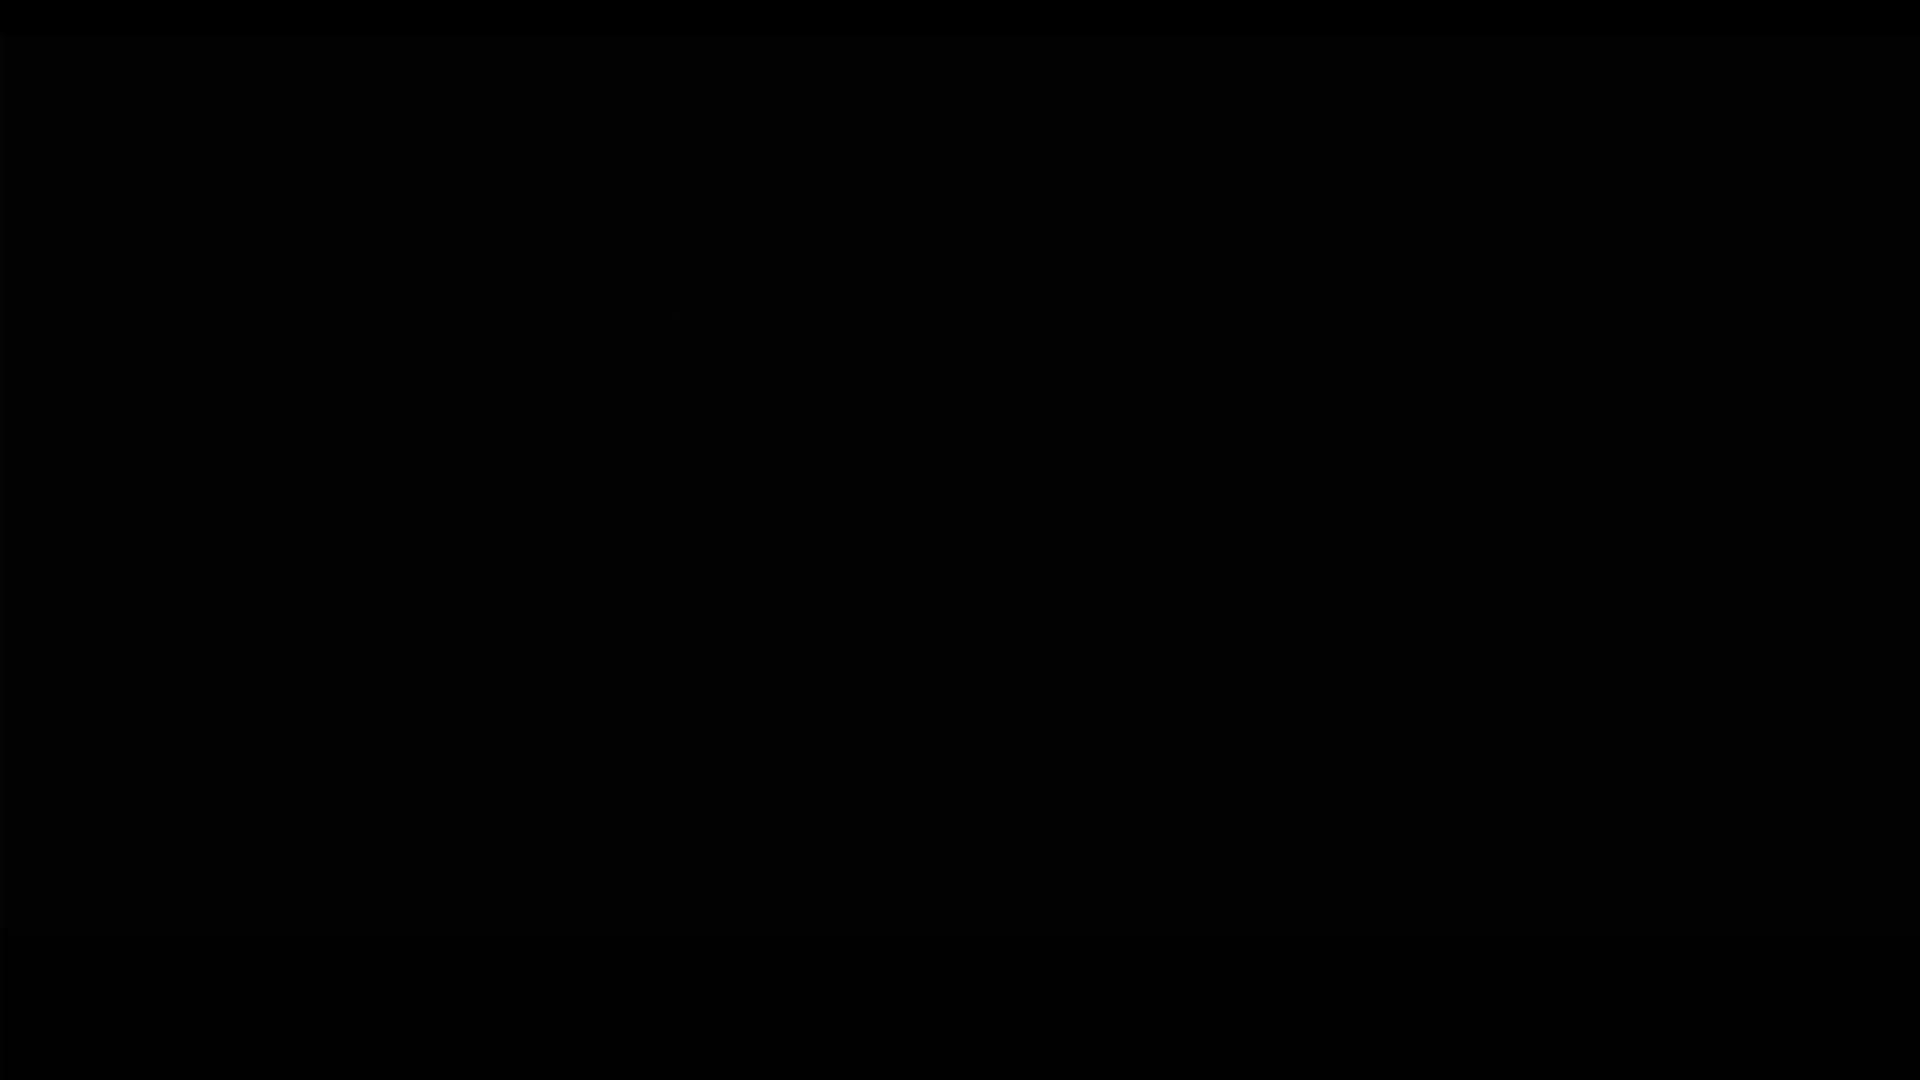

frame_000030.jpg


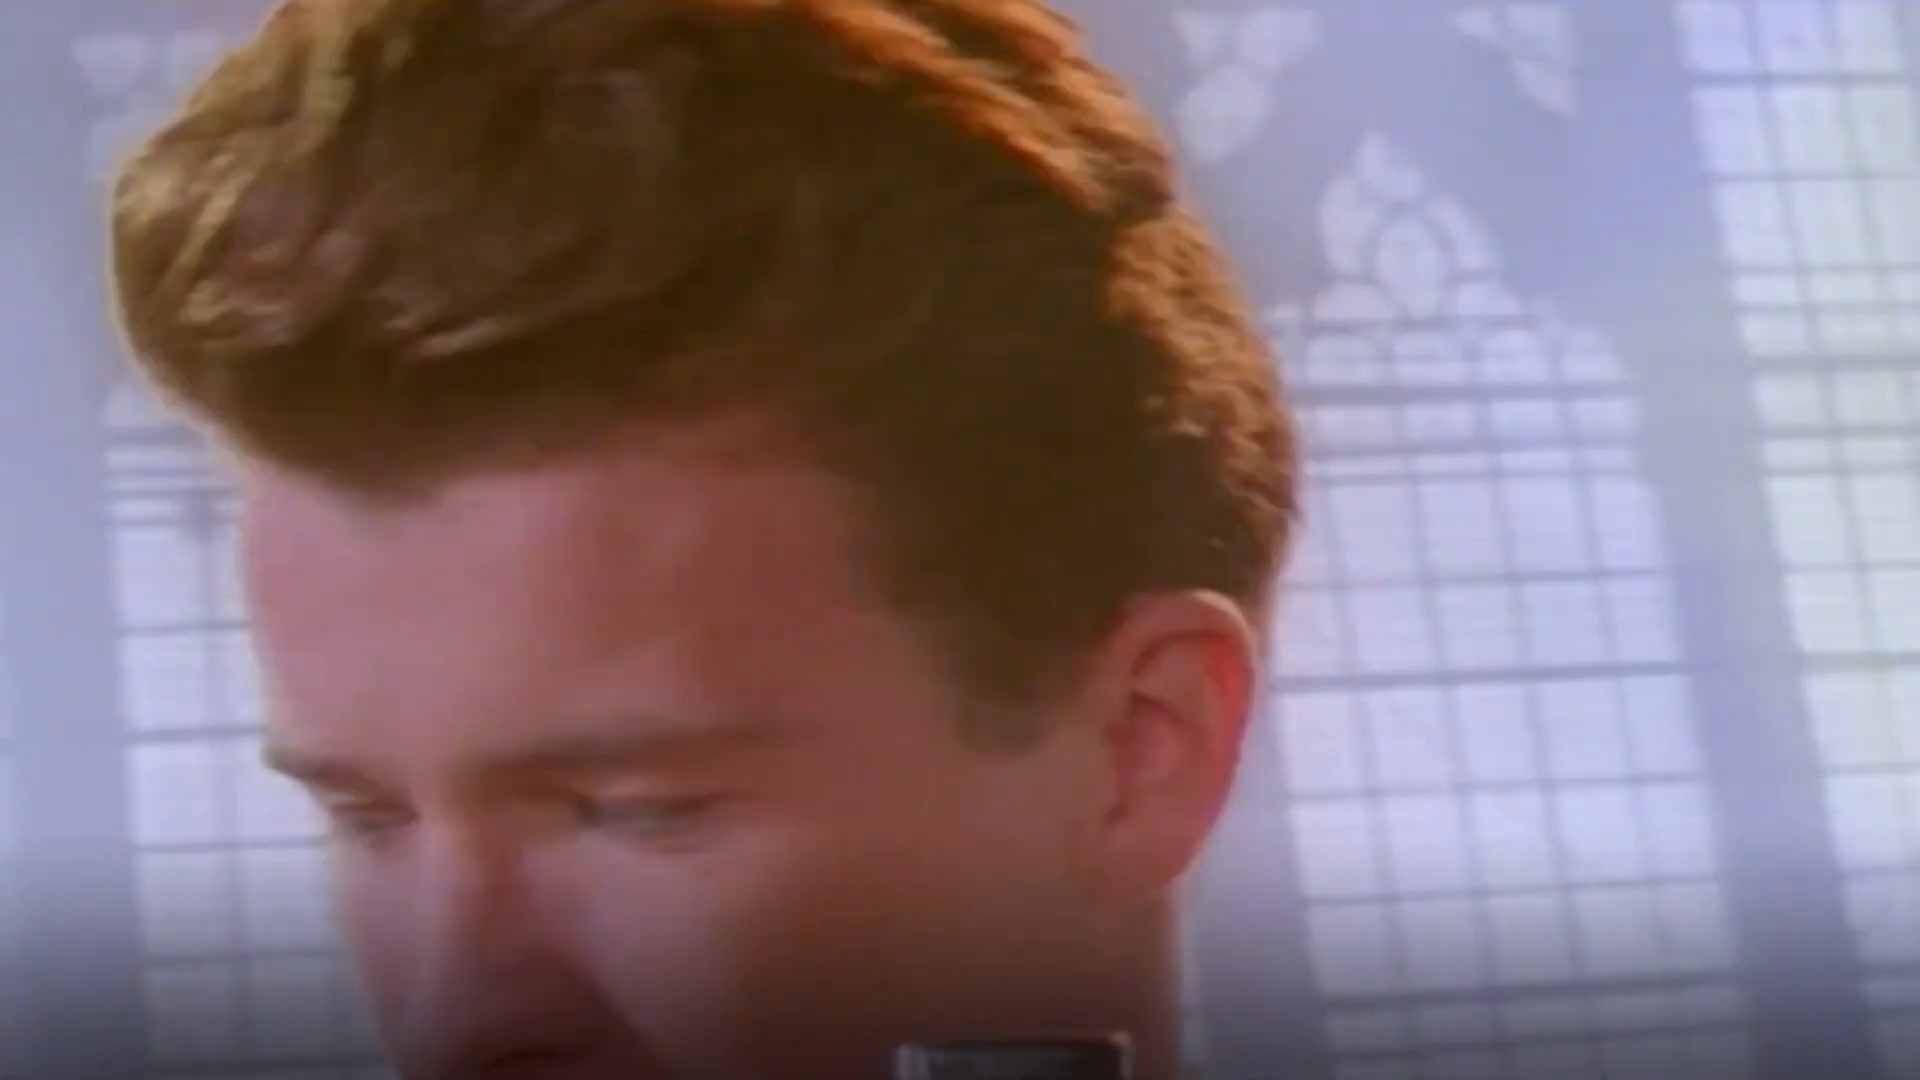

frame_000060.jpg


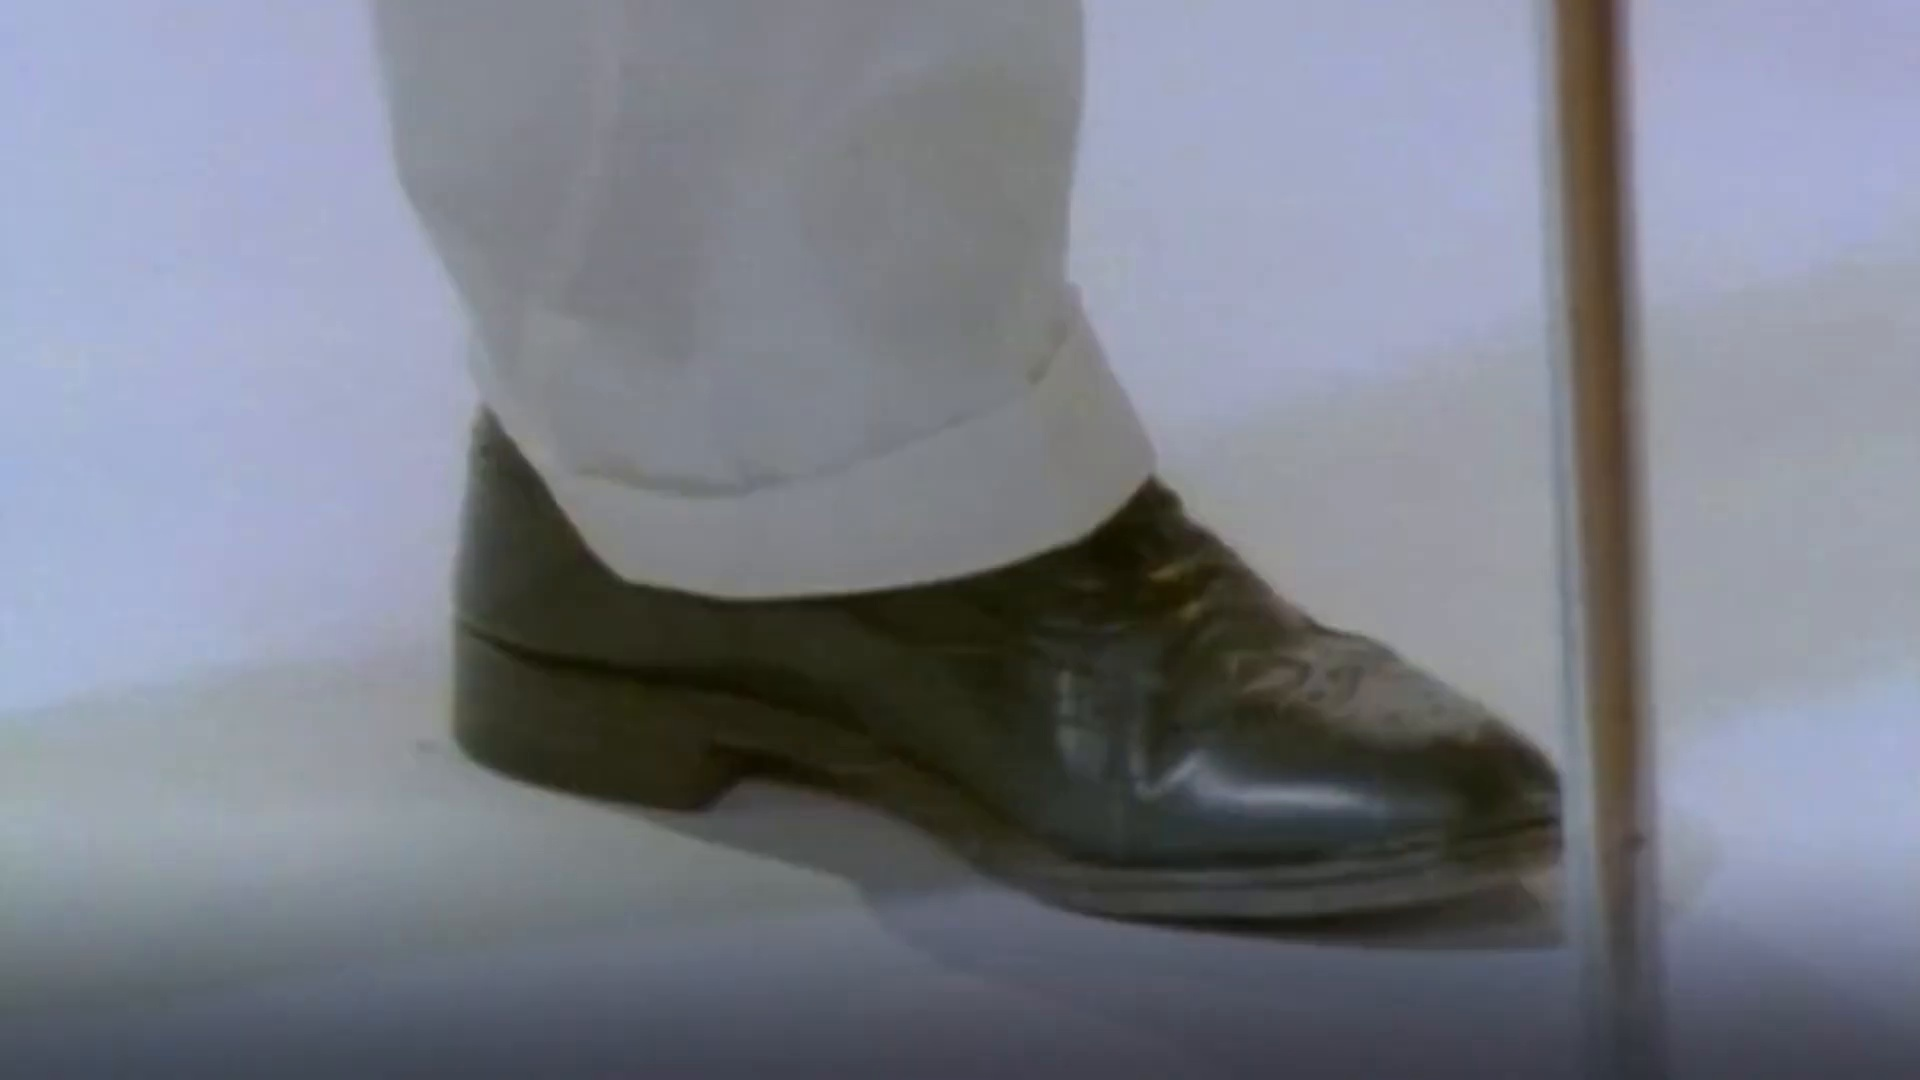

In [ ]:
# Показать первые 3 кадра
from IPython.display import Image, display
frames = sorted(f for f in os.listdir(FRAMES_DIR) if f.endswith('.jpg'))[:3]
for f in frames:
    print(f)
    display(Image(filename=f'{FRAMES_DIR}/{f}', width=400))